In [1]:
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("../data/dataset_selection.csv")

print("Aperçu du dataset :")
print(df.head())
print(f"\nNombre total d'images : {len(df)}")

class_counts = df['label'].value_counts()
print("\nRépartition des labels :")
print(class_counts)

Aperçu du dataset :
                                                path     label
0  /home/mathis/Memoire/data/glaucome/LAG/LAG/Tra...  glaucome
1  /home/mathis/Memoire/data/glaucome/LAG/LAG/Tra...  glaucome
2  /home/mathis/Memoire/data/glaucome/LAG/LAG/Tes...  glaucome
3  /home/mathis/Memoire/data/glaucome/ORIGA/ORIGA...  glaucome
4  /home/mathis/Memoire/data/glaucome/LAG/LAG/Tes...  glaucome

Nombre total d'images : 6208

Répartition des labels :
label
glaucome    1552
mda         1552
diabete     1552
normaux     1552
Name: count, dtype: int64


In [2]:
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(
    df,
    test_size=0.1,
    stratify=df['label'],
    random_state=42
)

print("Tailles des splits :")
print(f"Train : {len(df_train)}")
print(f"Test  : {len(df_test)}")

classes = sorted(df['label'].unique().tolist())
label_to_id = {c: i for i, c in enumerate(classes)}
print(f"\nClasses : {classes}")

Tailles des splits :
Train : 5587
Test  : 621

Classes : ['diabete', 'glaucome', 'mda', 'normaux']


In [3]:
def crop_black_border(img, thr=10, pad=10):
    if len(img.shape) == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray = img
    mask = gray > thr
    if not mask.any():
        return img
    ys, xs = np.where(mask)
    y0, y1 = ys.min(), ys.max()
    x0, x1 = xs.min(), xs.max()
    y0 = max(0, y0 - pad)
    x0 = max(0, x0 - pad)
    y1 = min(img.shape[0] - 1, y1 + pad)
    x1 = min(img.shape[1] - 1, x1 + pad)
    return img[y0:y1+1, x0:x1+1]

def load_image(path, size=(128, 128)):
    img = cv2.imread(path)
    if img is None:
        return None
    img = crop_black_border(img, thr=10, pad=10)
    img = cv2.resize(img, size)
    return img

print("Fonctions de prétraitement définies ✓")

Fonctions de prétraitement définies ✓


In [4]:
from skimage.feature import hog

def extract_hog_features(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    features = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm='L2-Hys',
        feature_vector=True
    )
    return features

def extract_pixel_features(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return gray.flatten().astype(np.float32) / 255.0

print("Fonctions d'extraction de features définies ✓")
print(f"HOG sur image 128x128 donne {extract_hog_features(np.zeros((128, 128, 3), dtype=np.uint8)).shape[0]} features")
print(f"Pixels aplatis sur image 128x128 donne {128*128} features")

Fonctions d'extraction de features définies ✓
HOG sur image 128x128 donne 8100 features
Pixels aplatis sur image 128x128 donne 16384 features


In [5]:
def extract_all_features(df_subset, extract_func):
    features, labels, valid_indices = [], [], []
    for idx, row in tqdm(df_subset.iterrows(), total=len(df_subset)):
        img = load_image(row['path'])
        if img is None:
            continue
        features.append(extract_func(img))
        labels.append(label_to_id[row['label']])
        valid_indices.append(idx)
    return np.array(features), np.array(labels), valid_indices

print("Extraction des features pixels...")
X_train_pixels, y_train, _ = extract_all_features(df_train, extract_pixel_features)
X_test_pixels,  y_test,  _ = extract_all_features(df_test,  extract_pixel_features)

print(f"\nShape X_train_pixels : {X_train_pixels.shape}")
print(f"Shape X_test_pixels  : {X_test_pixels.shape}")

Extraction des features pixels...


100%|██████████| 621/621 [00:29<00:00, 20.91it/s]


Shape X_train_pixels : (5587, 16384)
Shape X_test_pixels  : (621, 16384)


In [6]:
print("Extraction des features HOG...")
X_train_hog, _, _ = extract_all_features(df_train, extract_hog_features)
X_test_hog,  _, _ = extract_all_features(df_test,  extract_hog_features)

print(f"\nShape X_train_hog : {X_train_hog.shape}")
print(f"Shape X_test_hog  : {X_test_hog.shape}")

Extraction des features HOG...


100%|██████████| 621/621 [00:32<00:00, 19.20it/s]


Shape X_train_hog : (5587, 8100)
Shape X_test_hog  : (621, 8100)


In [7]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler_pixels = StandardScaler()
X_train_pixels_scaled = scaler_pixels.fit_transform(X_train_pixels)
X_test_pixels_scaled  = scaler_pixels.transform(X_test_pixels)

print(f"Shape X_train_pixels_scaled : {X_train_pixels_scaled.shape}")
print("PCA sera testée avec différents n_components dans le RandomizedSearchCV")

Shape X_train_pixels_scaled : (5587, 16384)
PCA sera testée avec différents n_components dans le RandomizedSearchCV


In [8]:
scaler_hog = StandardScaler()
X_train_hog_scaled = scaler_hog.fit_transform(X_train_hog)
X_test_hog_scaled  = scaler_hog.transform(X_test_hog)

X_train_combined_raw = np.hstack([X_train_pixels_scaled, X_train_hog_scaled])
X_test_combined_raw  = np.hstack([X_test_pixels_scaled,  X_test_hog_scaled])

n_pixel_features = X_train_pixels_scaled.shape[1]
n_hog_features   = X_train_hog_scaled.shape[1]

print(f"Shape X_train_hog_scaled     : {X_train_hog_scaled.shape}")
print(f"Shape X_train_combined_raw   : {X_train_combined_raw.shape}")
print(f"  - Colonnes pixels : 0 à {n_pixel_features - 1}")
print(f"  - Colonnes HOG    : {n_pixel_features} à {n_pixel_features + n_hog_features - 1}")

Shape X_train_hog_scaled     : (5587, 8100)
Shape X_train_combined_raw   : (5587, 24484)
  - Colonnes pixels : 0 à 16383
  - Colonnes HOG    : 16384 à 24483


In [9]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

mlp_params = {
    'hidden_layer_sizes': [
        (256,),
        (512,),
        (256, 128),
        (512, 256),
        (512, 256, 128),
    ],
    'activation':          ['relu', 'tanh'],
    'alpha':               [1e-4, 1e-3, 1e-2],
    'learning_rate_init':  [1e-3, 5e-4, 1e-4],
}

pca_components = [30, 50, 75, 100, 125, 150]

MLP_COMMON = dict(
    max_iter=200,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    random_state=42,
)

print("Paramètres MLP à tester :")
for key, values in mlp_params.items():
    print(f"  {key}: {values}")
print(f"\nComposantes PCA à tester : {pca_components}")
print("\nParamètres fixes :")
for k, v in MLP_COMMON.items():
    print(f"  {k}: {v}")

Paramètres MLP à tester :
  hidden_layer_sizes: [(256,), (512,), (256, 128), (512, 256), (512, 256, 128)]
  activation: ['relu', 'tanh']
  alpha: [0.0001, 0.001, 0.01]
  learning_rate_init: [0.001, 0.0005, 0.0001]

Composantes PCA à tester : [30, 50, 75, 100, 125, 150]

Paramètres fixes :
  max_iter: 200
  early_stopping: True
  validation_fraction: 0.1
  n_iter_no_change: 10
  random_state: 42


In [10]:
results = {}

# ============================================================
# 1) PCA seul : Pipeline(PCA -> MLP)
# ============================================================
print("="*60)
print("RandomizedSearch pour : PCA (n_components dans la grille)")
print("="*60)

pipe_pca = Pipeline([
    ('pca', PCA(random_state=42)),
    ('mlp', MLPClassifier(**MLP_COMMON))
])

param_grid_pca = {
    'pca__n_components': pca_components,
    **{f'mlp__{k}': v for k, v in mlp_params.items()}
}

grid_pca = RandomizedSearchCV(
    pipe_pca, param_grid_pca,
    n_iter=50, cv=3, scoring='accuracy',
    n_jobs=2, verbose=1, random_state=42
)
grid_pca.fit(X_train_pixels_scaled, y_train)

print(f"\nMeilleurs paramètres : {grid_pca.best_params_}")
print(f"Meilleur score CV    : {grid_pca.best_score_:.4f}")

results['PCA'] = {
    'best_model':    grid_pca.best_estimator_,
    'best_params':   grid_pca.best_params_,
    'best_cv_score': grid_pca.best_score_,
    'X_test':        X_test_pixels_scaled,
}

RandomizedSearch pour : PCA (n_components dans la grille)
Fitting 3 folds for each of 50 candidates, totalling 150 fits

Meilleurs paramètres : {'pca__n_components': 150, 'mlp__learning_rate_init': 0.001, 'mlp__hidden_layer_sizes': (512, 256, 128), 'mlp__alpha': 0.0001, 'mlp__activation': 'relu'}
Meilleur score CV    : 0.7589


In [11]:
# ============================================================
# 2) HOG seul : MLP directement
# ============================================================
print("="*60)
print("RandomizedSearch pour : HOG")
print("="*60)

grid_hog = RandomizedSearchCV(
    MLPClassifier(**MLP_COMMON), mlp_params,
    n_iter=50, cv=3, scoring='accuracy',
    n_jobs=2, verbose=1, random_state=42
)
grid_hog.fit(X_train_hog_scaled, y_train)

print(f"\nMeilleurs paramètres : {grid_hog.best_params_}")
print(f"Meilleur score CV    : {grid_hog.best_score_:.4f}")

results['HOG'] = {
    'best_model':    grid_hog.best_estimator_,
    'best_params':   grid_hog.best_params_,
    'best_cv_score': grid_hog.best_score_,
    'X_test':        X_test_hog_scaled,
}

RandomizedSearch pour : HOG
Fitting 3 folds for each of 50 candidates, totalling 150 fits

Meilleurs paramètres : {'learning_rate_init': 0.001, 'hidden_layer_sizes': (512, 256, 128), 'alpha': 0.001, 'activation': 'relu'}
Meilleur score CV    : 0.7661


In [12]:
# ============================================================
# 3) PCA + HOG : ColumnTransformer(PCA pixels, passthrough HOG) -> MLP
# ============================================================
print("="*60)
print("RandomizedSearch pour : PCA + HOG (n_components dans la grille)")
print("="*60)

pixel_cols = list(range(n_pixel_features))
hog_cols   = list(range(n_pixel_features, n_pixel_features + n_hog_features))

pipe_combined = Pipeline([
    ('features', ColumnTransformer([
        ('pca', PCA(random_state=42), pixel_cols),
        ('hog', 'passthrough',        hog_cols)
    ])),
    ('mlp', MLPClassifier(**MLP_COMMON))
])

param_grid_combined = {
    'features__pca__n_components': pca_components,
    **{f'mlp__{k}': v for k, v in mlp_params.items()}
}

grid_combined = RandomizedSearchCV(
    pipe_combined, param_grid_combined,
    n_iter=50, cv=3, scoring='accuracy',
    n_jobs=2, verbose=1, random_state=42
)
grid_combined.fit(X_train_combined_raw, y_train)

print(f"\nMeilleurs paramètres : {grid_combined.best_params_}")
print(f"Meilleur score CV    : {grid_combined.best_score_:.4f}")

results['PCA + HOG'] = {
    'best_model':    grid_combined.best_estimator_,
    'best_params':   grid_combined.best_params_,
    'best_cv_score': grid_combined.best_score_,
    'X_test':        X_test_combined_raw,
}

RandomizedSearch pour : PCA + HOG (n_components dans la grille)
Fitting 3 folds for each of 50 candidates, totalling 150 fits

Meilleurs paramètres : {'mlp__learning_rate_init': 0.0005, 'mlp__hidden_layer_sizes': (512, 256, 128), 'mlp__alpha': 0.001, 'mlp__activation': 'relu', 'features__pca__n_components': 100}
Meilleur score CV    : 0.7788


In [13]:
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

print("\n" + "="*70)
print("ÉVALUATION SUR LE JEU DE TEST")
print("="*70)

comparison_data = []

for name, data in results.items():
    y_pred = data['best_model'].predict(data['X_test'])

    acc  = accuracy_score(y_test, y_pred)
    bacc = balanced_accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_test, y_pred,    average='macro', zero_division=0)
    f1   = f1_score(y_test, y_pred,        average='macro', zero_division=0)

    results[name]['test_accuracy'] = acc
    results[name]['test_f1']       = f1
    results[name]['y_pred']        = y_pred

    comparison_data.append({
        'Approche':      name,
        'CV Score':      data['best_cv_score'],
        'Test Accuracy': acc,
        'Balanced Acc':  bacc,
        'Precision':     prec,
        'Recall':        rec,
        'F1 Score':      f1,
    })

    print(f"\n--- {name} ---")
    print(f"Meilleurs paramètres : {data['best_params']}")
    print(f"Test Accuracy        : {acc:.4f}")
    print(f"Balanced Accuracy    : {bacc:.4f}")
    print(f"F1 Score (macro)     : {f1:.4f}")

comparison_df = pd.DataFrame(comparison_data).round(4)

print("\n" + "="*70)
print("TABLEAU COMPARATIF DES 3 APPROCHES")
print("="*70)
print(comparison_df.to_string(index=False))

best_approach = comparison_df.loc[comparison_df['Test Accuracy'].idxmax(), 'Approche']
print(f"\n✅ Meilleure approche : {best_approach}")


ÉVALUATION SUR LE JEU DE TEST

--- PCA ---
Meilleurs paramètres : {'pca__n_components': 150, 'mlp__learning_rate_init': 0.001, 'mlp__hidden_layer_sizes': (512, 256, 128), 'mlp__alpha': 0.0001, 'mlp__activation': 'relu'}
Test Accuracy        : 0.7552
Balanced Accuracy    : 0.7552
F1 Score (macro)     : 0.7537

--- HOG ---
Meilleurs paramètres : {'learning_rate_init': 0.001, 'hidden_layer_sizes': (512, 256, 128), 'alpha': 0.001, 'activation': 'relu'}
Test Accuracy        : 0.7568
Balanced Accuracy    : 0.7568
F1 Score (macro)     : 0.7536

--- PCA + HOG ---
Meilleurs paramètres : {'mlp__learning_rate_init': 0.0005, 'mlp__hidden_layer_sizes': (512, 256, 128), 'mlp__alpha': 0.001, 'mlp__activation': 'relu', 'features__pca__n_components': 100}
Test Accuracy        : 0.7617
Balanced Accuracy    : 0.7616
F1 Score (macro)     : 0.7538

TABLEAU COMPARATIF DES 3 APPROCHES
 Approche  CV Score  Test Accuracy  Balanced Acc  Precision  Recall  F1 Score
      PCA    0.7589         0.7552        0.75

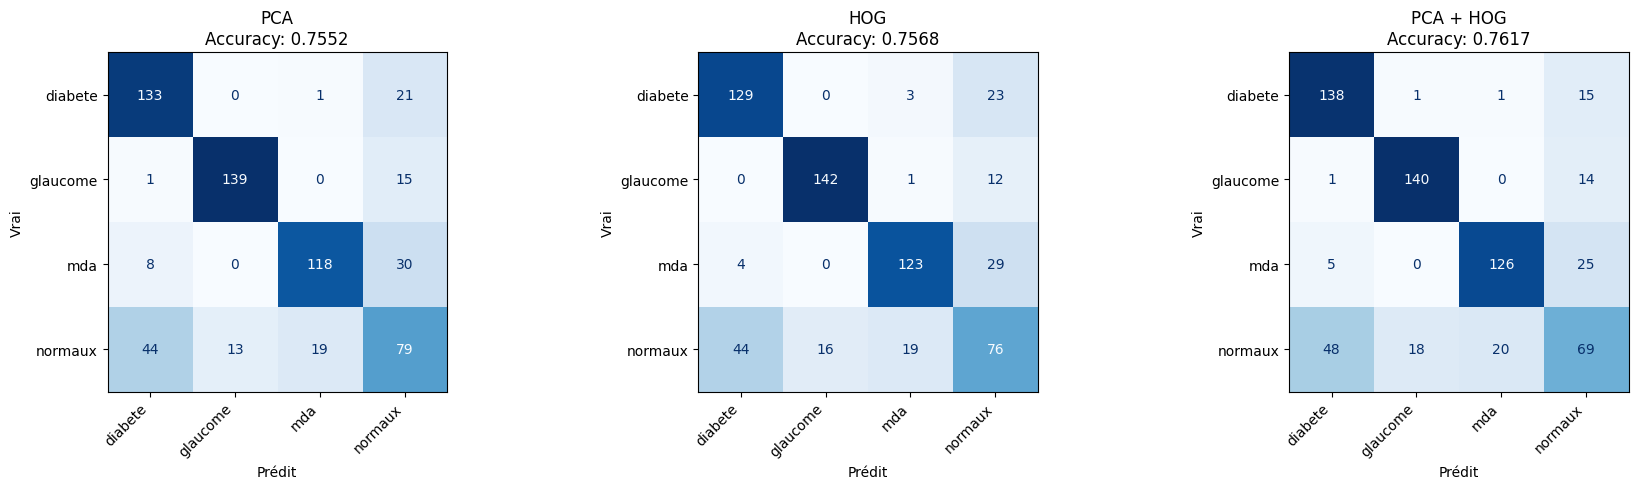

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, data) in enumerate(results.items()):
    cm = confusion_matrix(y_test, data['y_pred'], labels=list(range(len(classes))))
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes).plot(
        ax=axes[idx], values_format='d', cmap='Blues', colorbar=False)
    axes[idx].set_title(f'{name}\nAccuracy: {data["test_accuracy"]:.4f}')
    axes[idx].set_xlabel('Prédit')
    axes[idx].set_ylabel('Vrai')
    plt.setp(axes[idx].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [15]:
print("\n" + "="*70)
print(f"RAPPORT DÉTAILLÉ POUR LA MEILLEURE APPROCHE : {best_approach}")
print("="*70)

best_data = results[best_approach]
print("\nMeilleurs paramètres trouvés :")
for param, value in best_data['best_params'].items():
    print(f"  {param}: {value}")

print("\nRapport de classification :")
print(classification_report(y_test, best_data['y_pred'], target_names=classes, zero_division=0))


RAPPORT DÉTAILLÉ POUR LA MEILLEURE APPROCHE : PCA + HOG

Meilleurs paramètres trouvés :
  mlp__learning_rate_init: 0.0005
  mlp__hidden_layer_sizes: (512, 256, 128)
  mlp__alpha: 0.001
  mlp__activation: relu
  features__pca__n_components: 100

Rapport de classification :
              precision    recall  f1-score   support

     diabete       0.72      0.89      0.80       155
    glaucome       0.88      0.90      0.89       155
         mda       0.86      0.81      0.83       156
     normaux       0.56      0.45      0.50       155

    accuracy                           0.76       621
   macro avg       0.75      0.76      0.75       621
weighted avg       0.75      0.76      0.75       621



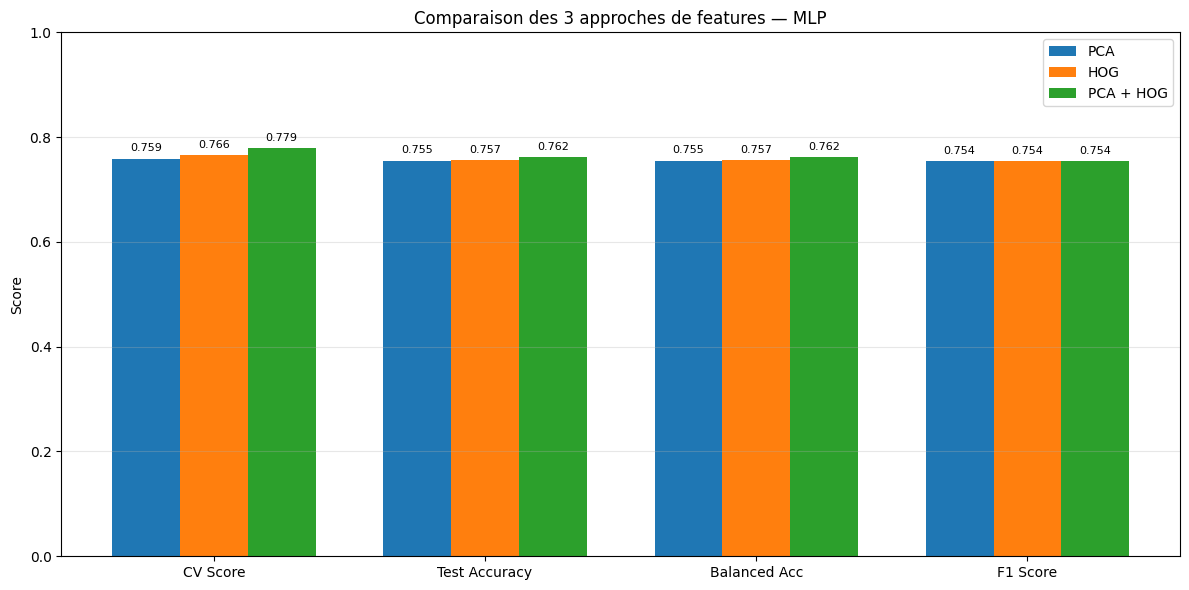

In [16]:
metrics = ['CV Score', 'Test Accuracy', 'Balanced Acc', 'F1 Score']
x     = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

for i, approach in enumerate(['PCA', 'HOG', 'PCA + HOG']):
    row    = comparison_df[comparison_df['Approche'] == approach].iloc[0]
    values = [row['CV Score'], row['Test Accuracy'], row['Balanced Acc'], row['F1 Score']]
    ax.bar(x + i * width, values, width, label=approach)
    for j, v in enumerate(values):
        ax.text(x[j] + i * width, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_ylabel('Score')
ax.set_title('Comparaison des 3 approches de features — MLP')
ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

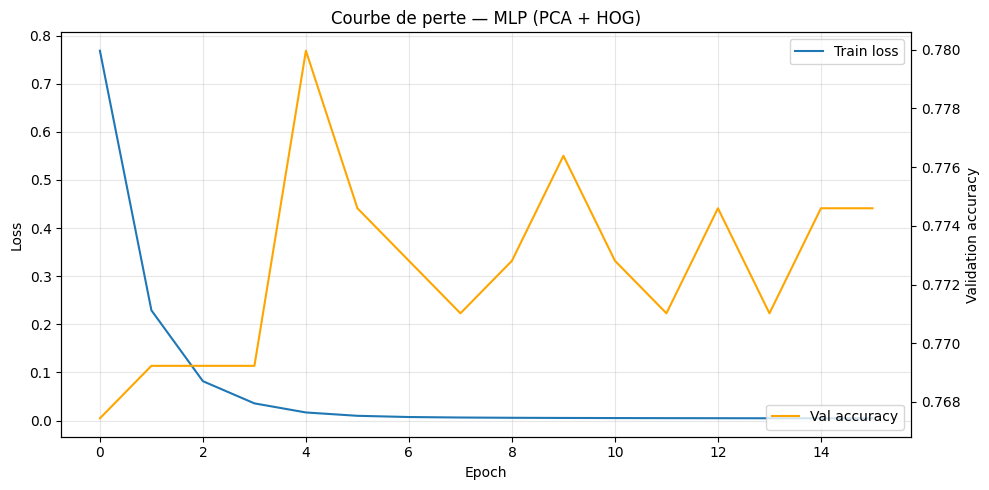

Nombre d'epochs effectuées : 16
Test accuracy (meilleur modèle) : 0.7617


In [17]:
# Courbe de perte du meilleur modèle (ré-entraîné seul pour accéder à loss_curve_)
best_params = best_data['best_params']

# Extraire les paramètres MLP (sans le préfixe pipeline)
mlp_keys = {k.replace('mlp__', ''): v for k, v in best_params.items() if k.startswith('mlp__')}
pca_n    = best_params.get('pca__n_components') or best_params.get('features__pca__n_components')

# Préparer X selon la meilleure approche
if best_approach == 'PCA':
    pca_final = PCA(n_components=pca_n, random_state=42).fit(X_train_pixels_scaled)
    X_tr = pca_final.transform(X_train_pixels_scaled)
    X_te = pca_final.transform(X_test_pixels_scaled)
elif best_approach == 'HOG':
    X_tr, X_te = X_train_hog_scaled, X_test_hog_scaled
else:
    from sklearn.compose import ColumnTransformer
    ct = ColumnTransformer([
        ('pca', PCA(n_components=pca_n, random_state=42), list(range(n_pixel_features))),
        ('hog', 'passthrough', list(range(n_pixel_features, n_pixel_features + n_hog_features)))
    ])
    X_tr = ct.fit_transform(X_train_combined_raw)
    X_te = ct.transform(X_test_combined_raw)

best_mlp = MLPClassifier(**mlp_keys, **MLP_COMMON)
best_mlp.fit(X_tr, y_train)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(best_mlp.loss_curve_, label='Train loss')
if hasattr(best_mlp, 'validation_scores_'):
    ax2 = ax.twinx()
    ax2.plot(best_mlp.validation_scores_, color='orange', label='Val accuracy')
    ax2.set_ylabel('Validation accuracy')
    ax2.legend(loc='lower right')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title(f'Courbe de perte — MLP ({best_approach})')
ax.legend(loc='upper right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Nombre d'epochs effectuées : {best_mlp.n_iter_}")
print(f"Test accuracy (meilleur modèle) : {accuracy_score(y_test, best_mlp.predict(X_te)):.4f}")